In [9]:
import os
from morph_utils.visuals import basic_morph_plot
from neuron_morphology.swc_io import morphology_from_swc
import matplotlib.pyplot as plt
from neuron_morphology.transforms.affine_transform import AffineTransform
from query import query_lims_for_layers
from fiducials import get_coords, convert_coords_str
from geometry import line

import filecmp


In [10]:
O_PATH = r'\\allen\programs\celltypes\workgroups\mousecelltypes\SarahWB\github_projects\primate_uprighting\testing\original'
U_PATH = r'\\allen\programs\celltypes\workgroups\mousecelltypes\SarahWB\github_projects\primate_uprighting\testing\upright'
C_PATH = r'\\allen\programs\celltypes\workgroups\mousecelltypes\SarahWB\github_projects\primate_uprighting\testing\upright_correct'

In [14]:
#check if upright swcs are correct 

for swc in os.listdir(U_PATH):
    if swc.endswith(".swc"):
        if os.path.isfile(os.path.join(C_PATH, swc)):
            upright_swc = os.path.join(U_PATH, swc)
            upright_swc_correct = os.path.join(C_PATH, swc)

            print(filecmp.cmp(upright_swc, upright_swc_correct, shallow=False))


FileNotFoundError: [WinError 3] The system cannot find the path specified: '\\\\allen\\programs\\celltypes\\workgroups\\mousecelltypes\\SarahWB\\github_projects\\primate_uprighting\\testing\\upright'

ERROR: Couldn't load layers for 1079081411


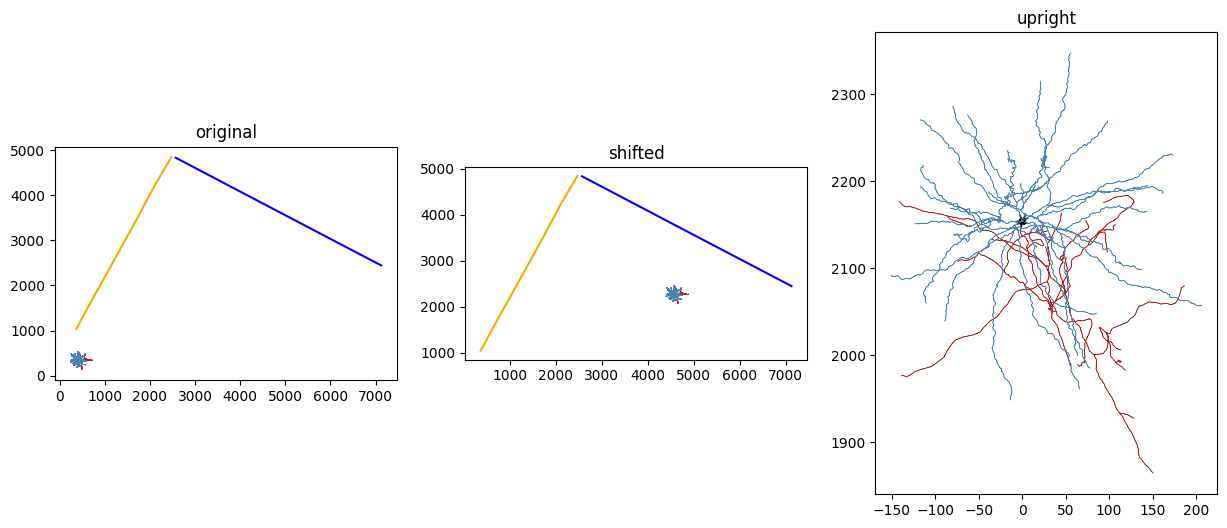

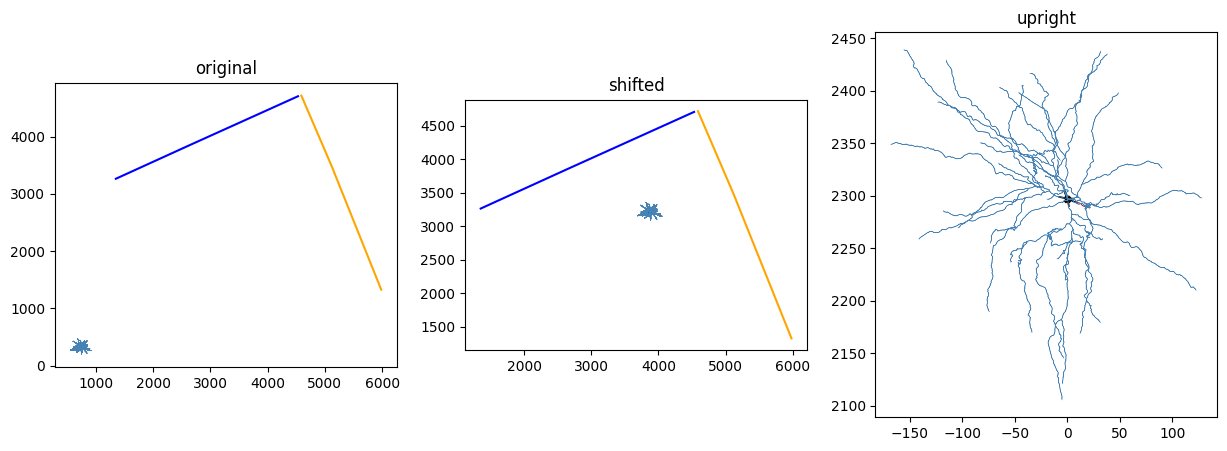

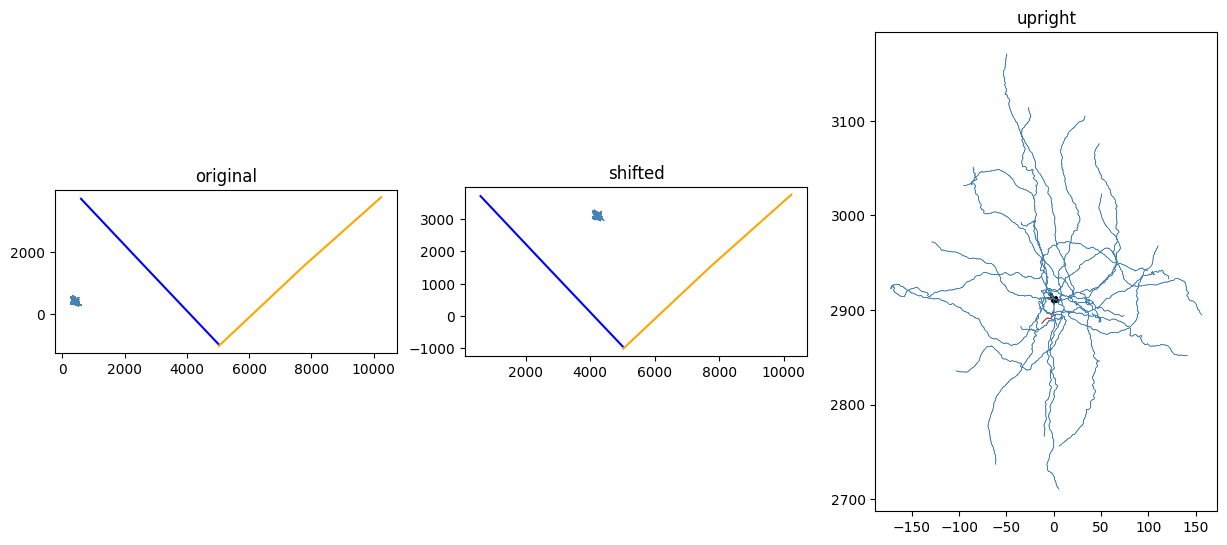

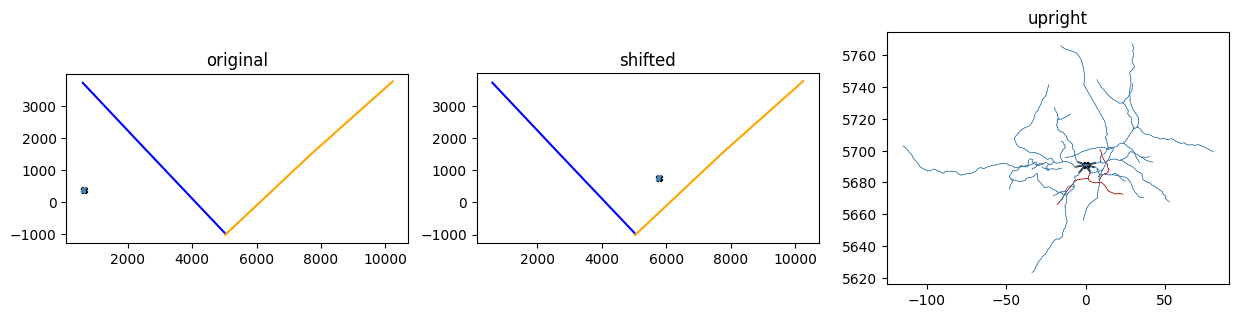

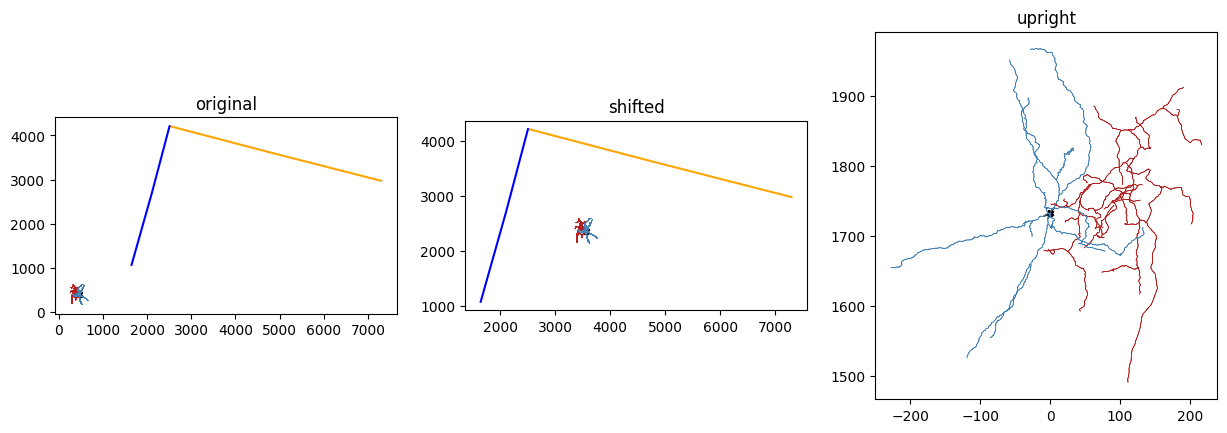

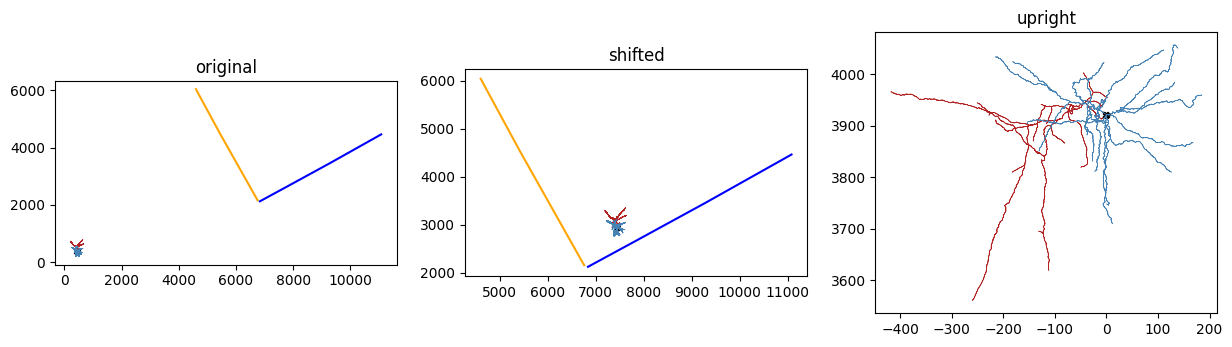

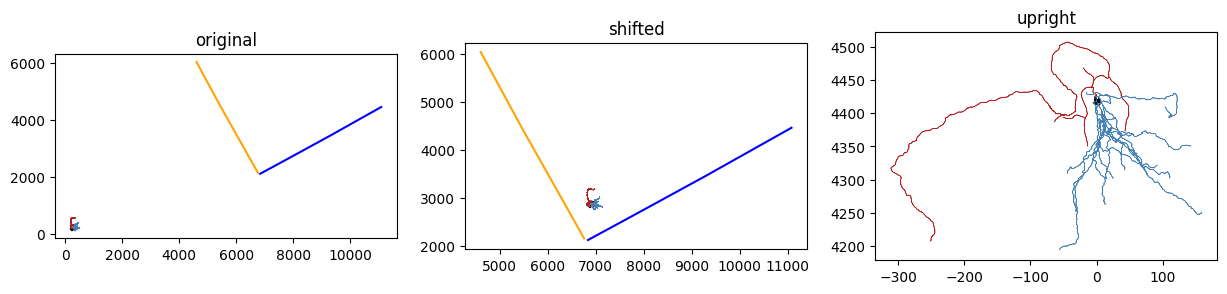

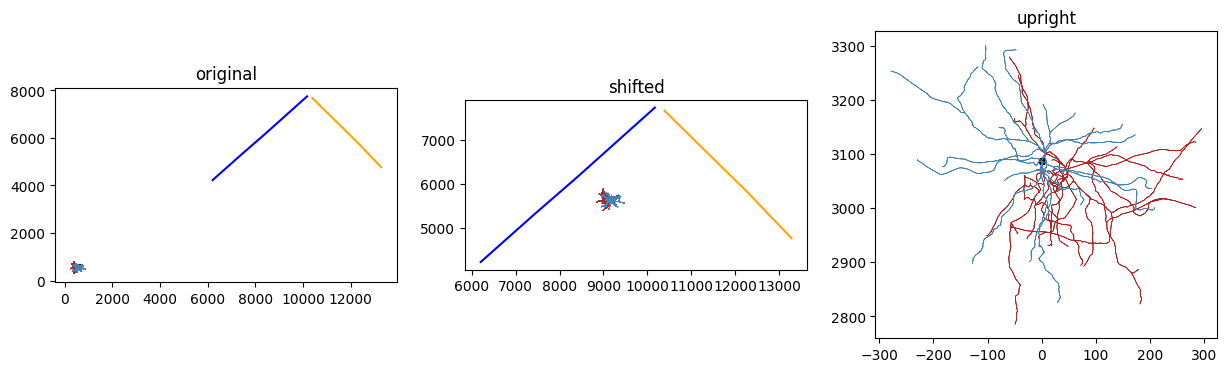

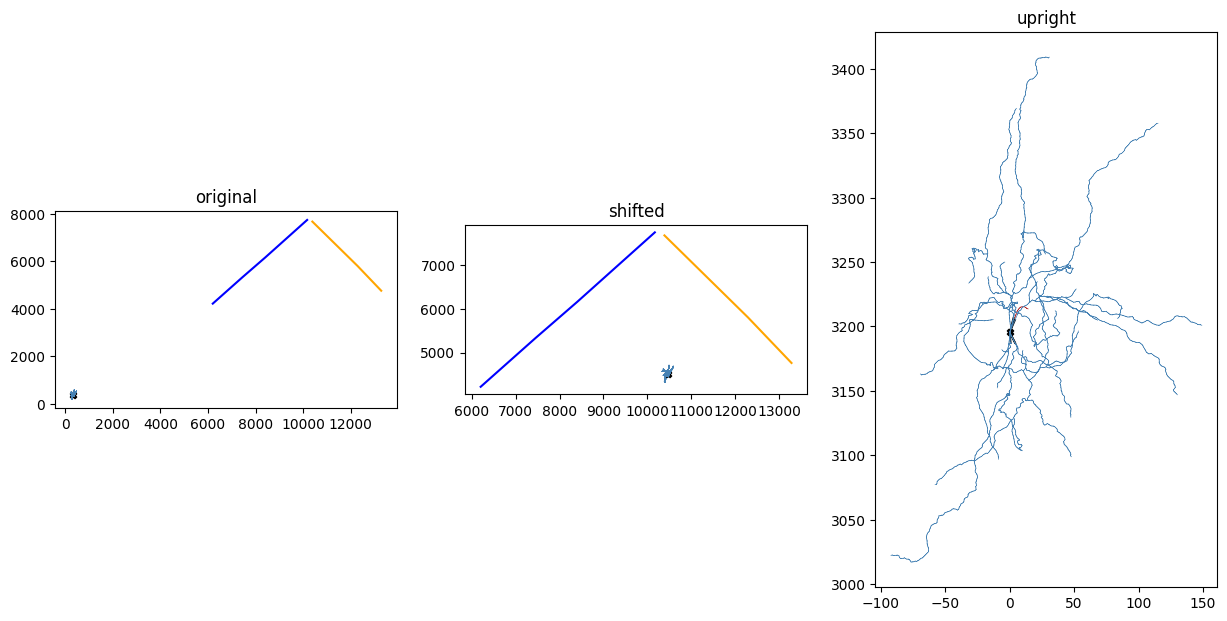

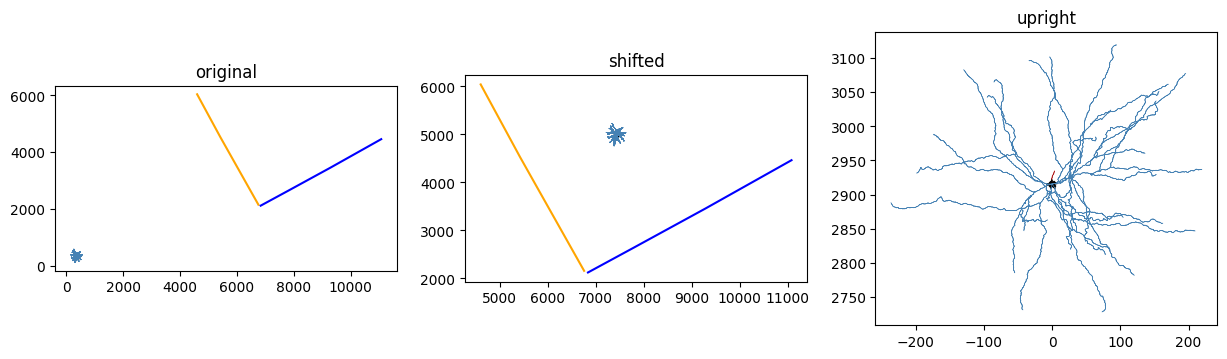

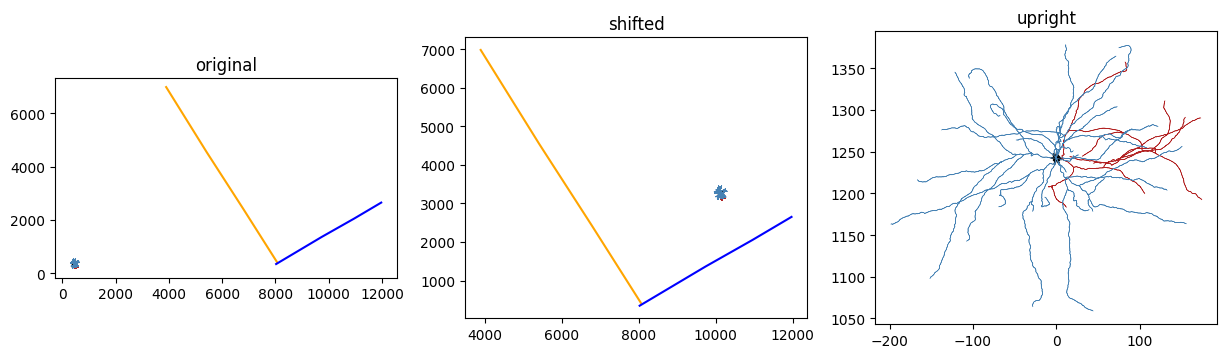

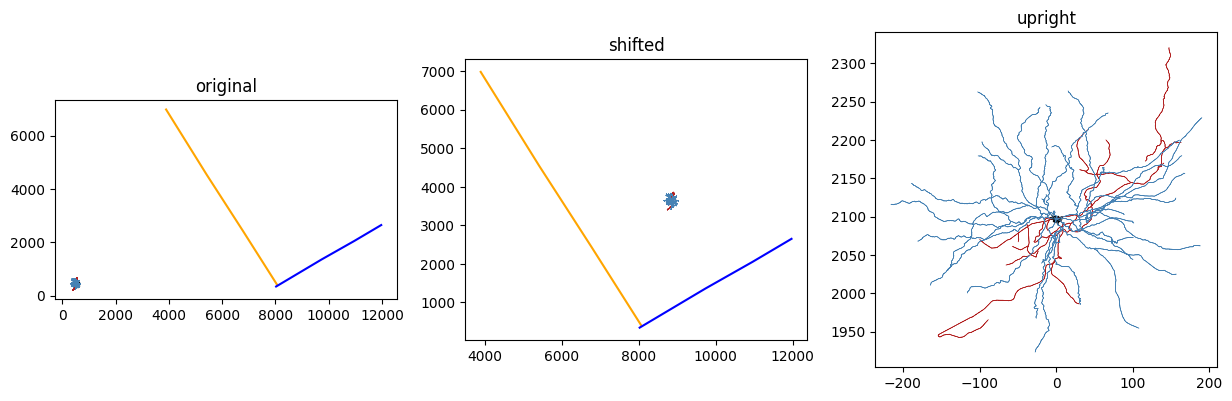

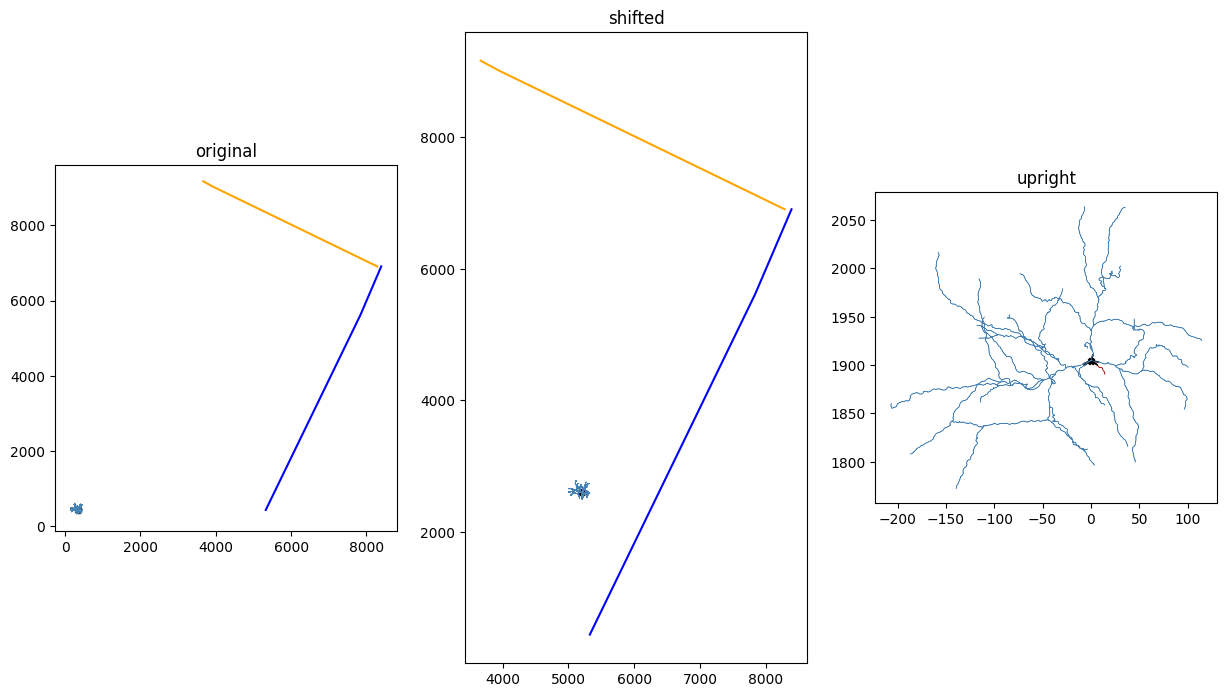

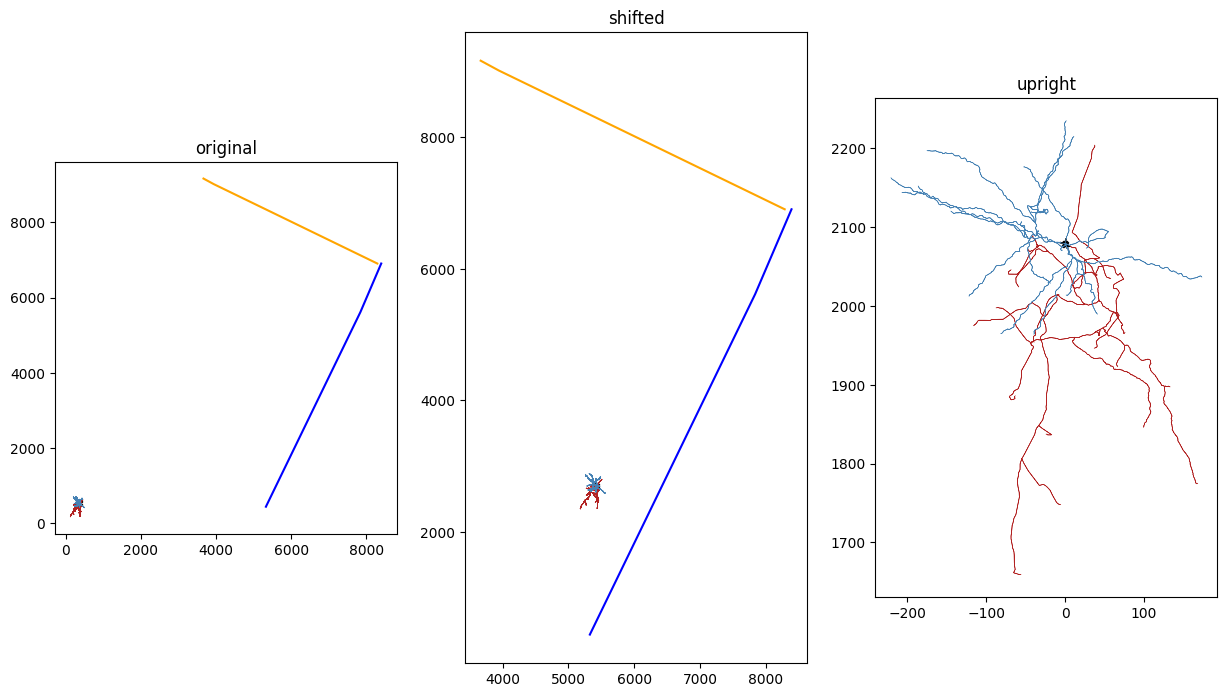

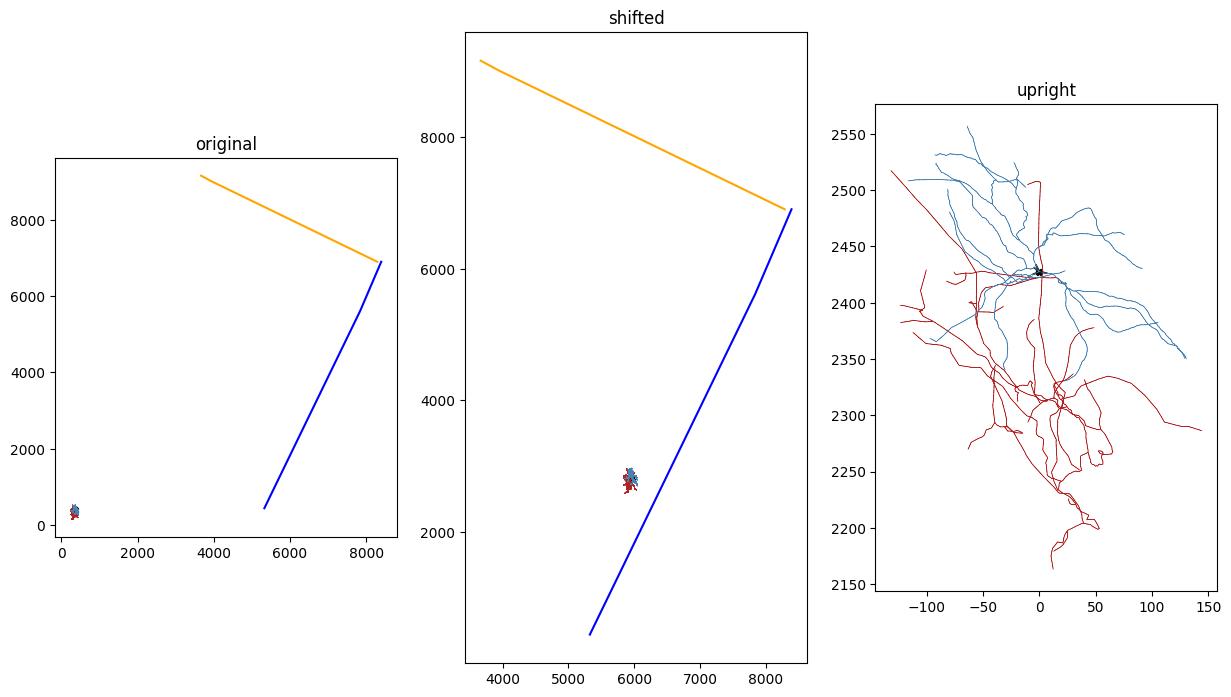

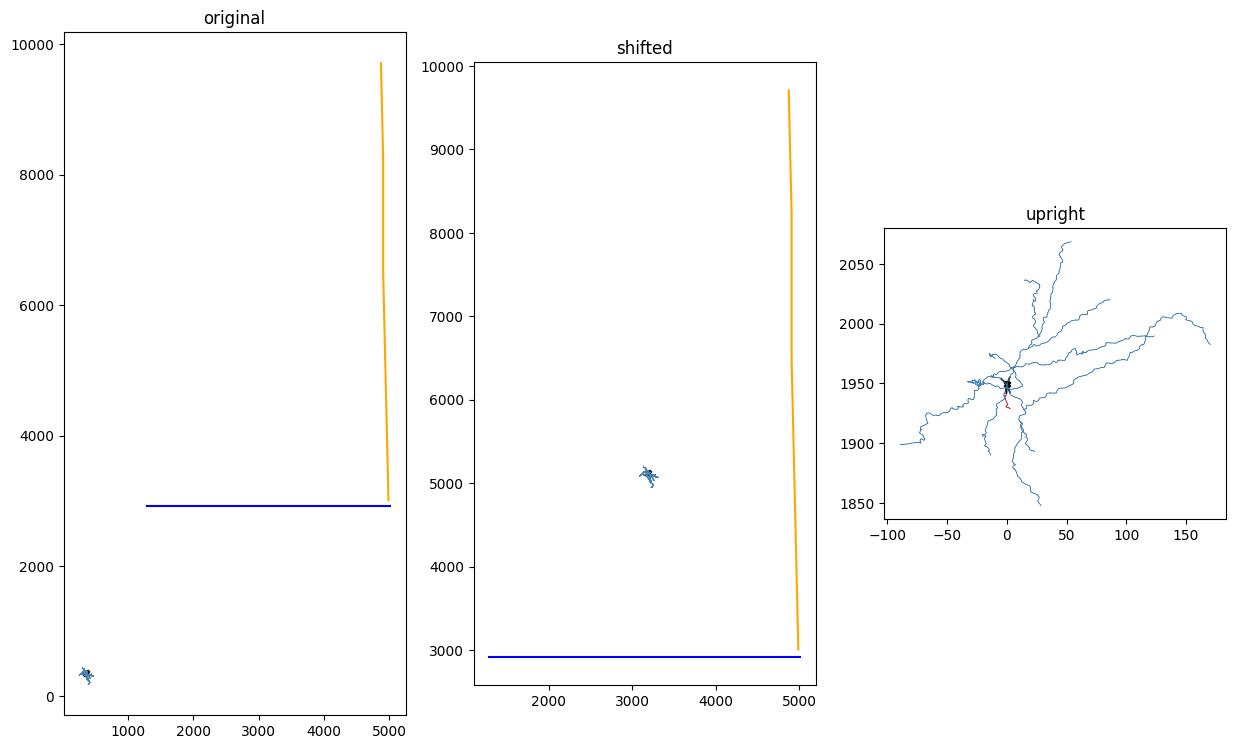

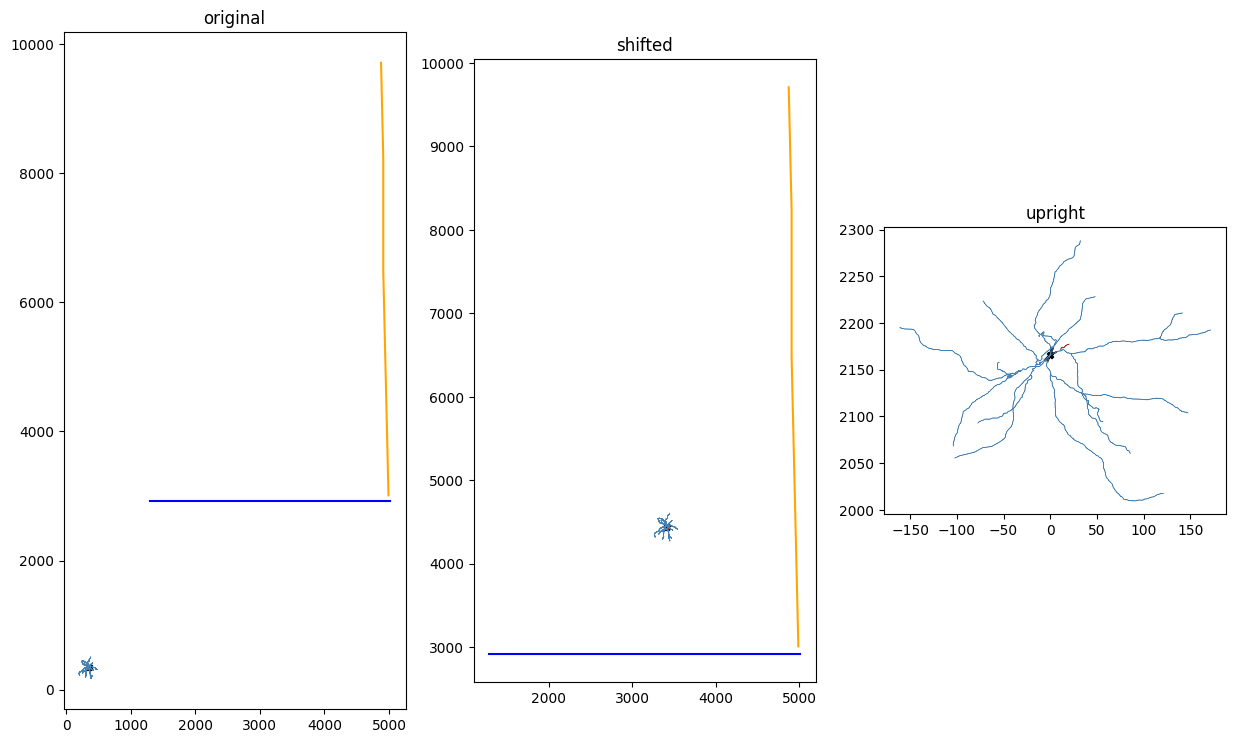

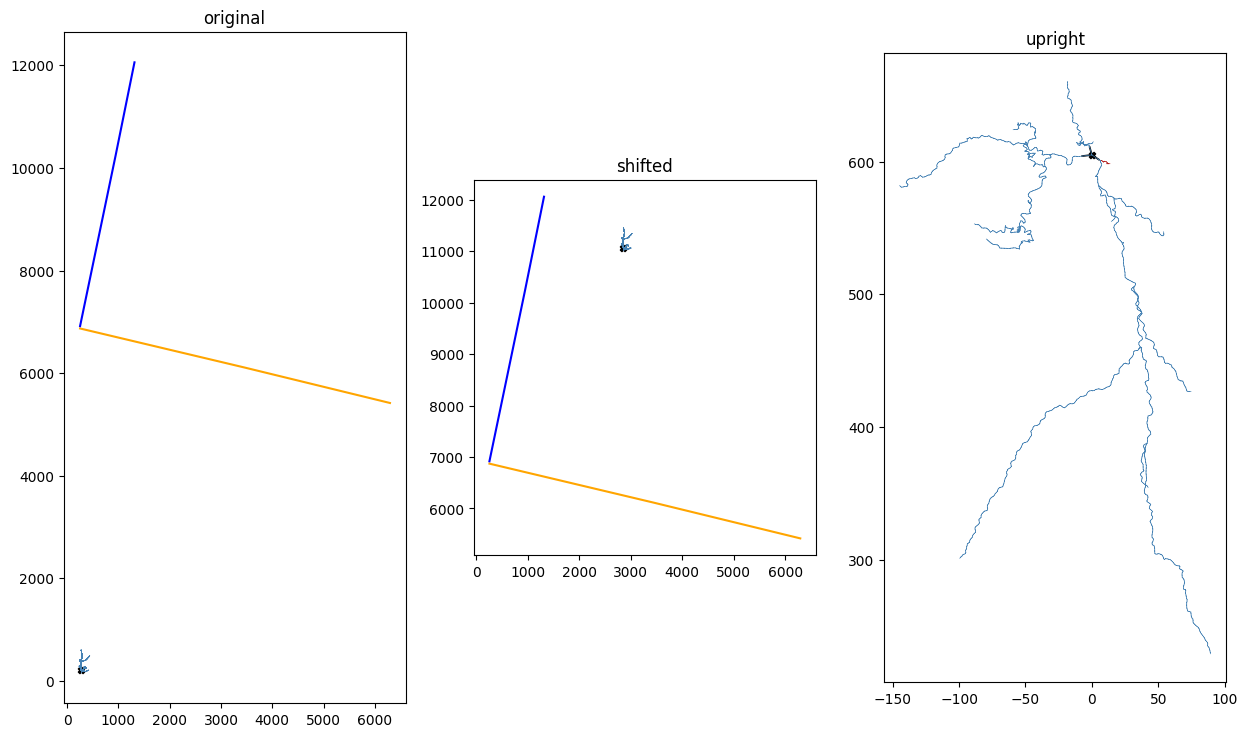

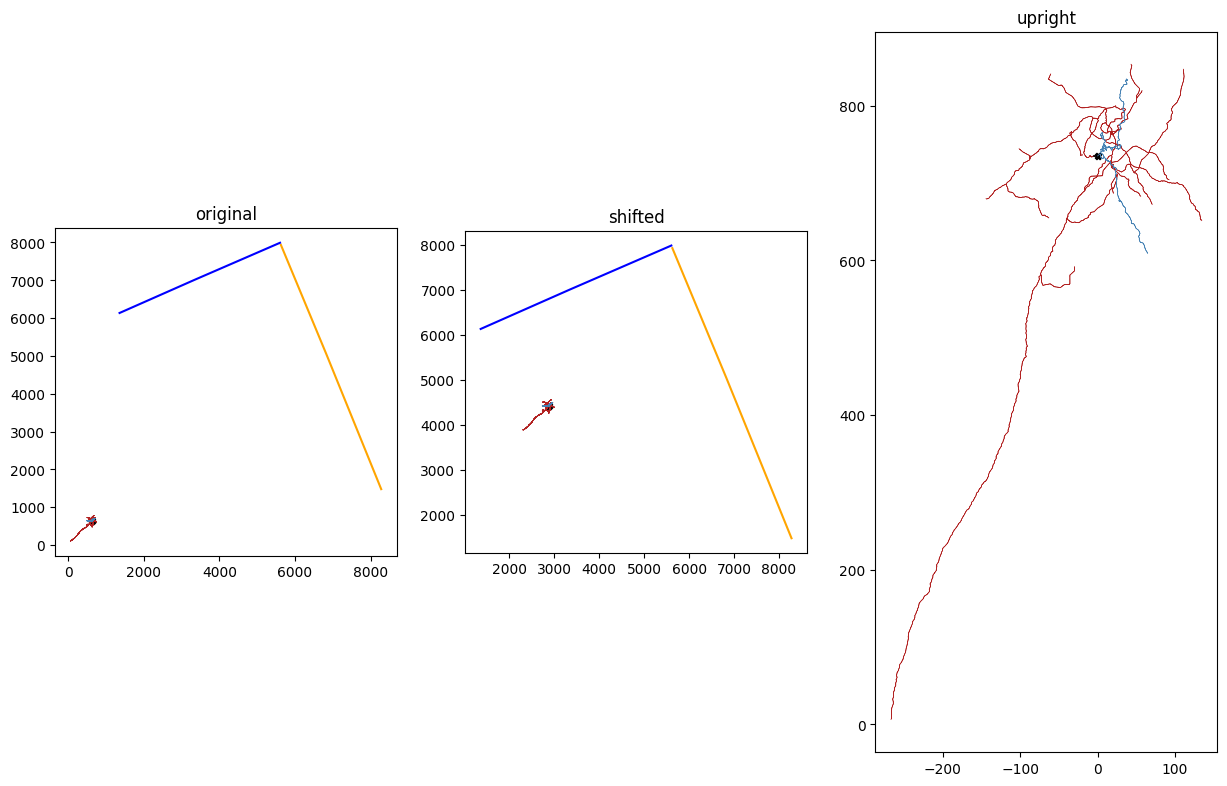

In [7]:
specimen_ids = ['1102613885', '1102623321', '1110880399', '1110896667',
                '1112128140', '1112760246', '1112741472', '1096755367',
                '1096738774', '1112811000', '1096716775', '1096732440',
                '1079081411', '1129691862', '1129687286', '1129673408',
                '1133704467', '1133695858', '1133464447', '1140841280']

layer_list = ["1", "2/3",  "4", "5", "6a", "6b"]

for specimen_id in specimen_ids:

    try:

        o_swc = os.path.join(O_PATH, str(specimen_id)+'.swc')
        u_swc = os.path.join(U_PATH, str(specimen_id)+'_upright.swc')
        o_nrn = morphology_from_swc(o_swc)
        s_nrn = morphology_from_swc(o_swc)
        u_nrn = morphology_from_swc(u_swc)

        ldf = query_lims_for_layers(specimen_id)
        try:soma_coords, pia_coords, wm_coords, layer_coords = get_coords(ldf, layer_list)
        except:print("ERROR: Couldn't load layers for {}".format(specimen_id))

        #Edit WM coords
        row = ldf[ldf.draw_type == 'Pia']
        res = row.res.values[0]  
        pcoords = row.poly_coords.values[0]
        plx, ply = convert_coords_str(pcoords)
        plx = plx * res
        ply = ply * res
        L1 = line([plx[0],ply[0]], [plx[-1], ply[-1]])


        #Add White Matter
        row = ldf[ldf.draw_type == 'White Matter']
        res = row.res.values[0]  
        wcoords = row.poly_coords.values[0]
        lx, ly = convert_coords_str(wcoords)
        lx = lx * res
        ly = ly * res
        L2 = line([lx[0],ly[0]], [lx[-1], ly[-1]])

        #shift original nrn to soma loc in layer drawings
        morph = s_nrn
        soma_node = morph.get_soma()
        soma_x = soma_coords["x"].mean()
        soma_y = soma_coords["y"].mean()
        aff = [1., 0., 0., 0., 1., 0., 0., 0., 1., -soma_node["x"] + soma_x, -soma_node["y"] + soma_y, 0.]
        translate_transform= AffineTransform.from_list(aff)
        moved_morph = translate_transform.transform_morphology(morph) # if you need the original object to remain unchanged do morph.clone()

        nrns = {0: {'nrn':o_nrn, 'title':'original'}, 
            1: {'nrn':moved_morph, 'title': 'shifted'},
            2: {'nrn':u_nrn, 'title':'upright'}}

        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,15), sharex=False, sharey=False)
        for i, ax in enumerate(axes):
            basic_morph_plot(nrns[i]['nrn'], ax)
            ax.set_aspect('equal')
            ax.set_title(nrns[i]['title'])
            if i < 2:
                ax.plot(pia_coords['x'],pia_coords['y'], 'orange')
                ax.plot(wm_coords['x'],wm_coords['y'], 'blue')

    except: continue

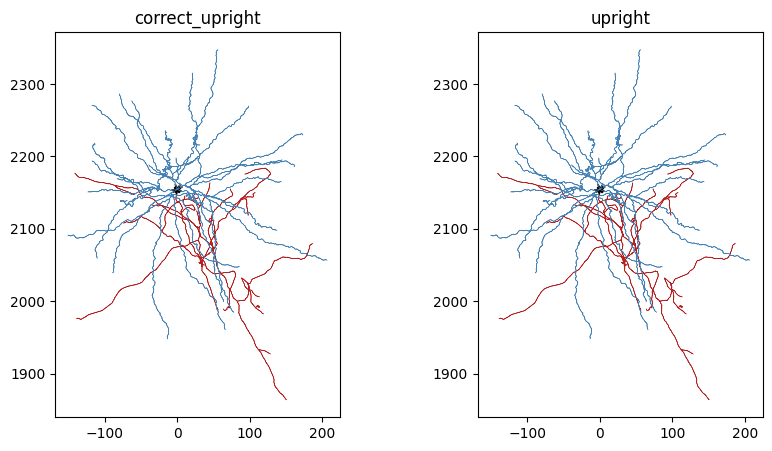

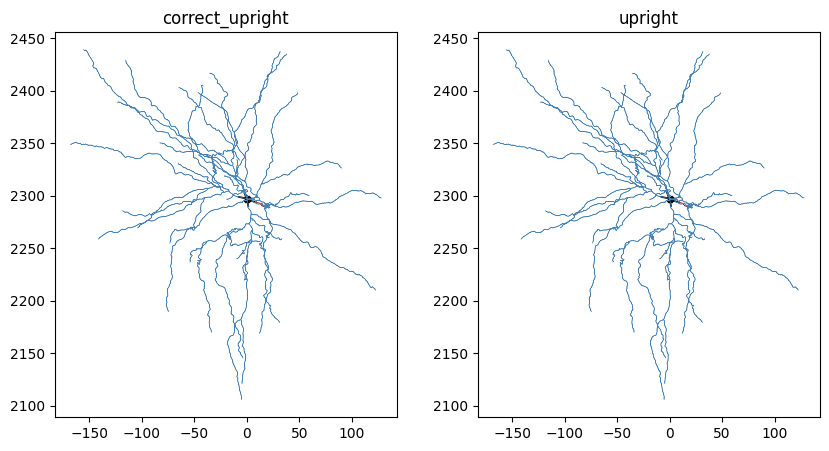

In [8]:
specimen_id = 1102613885 #flipped
specimen_id = 1102623321

specimen_ids = ['1102613885', '1102623321'] #, '1110880399', '1110896667',
                # '1112128140', '1112760246', '1112741472', '1096755367',
                # '1096738774', '1112811000', '1096716775', '1096732440',
                # '1079081411', '1129691862', '1129687286', '1129673408',
                # '1133704467', '1133695858', '1133464447', '1140841280']

for specimen_id in specimen_ids:

    try:

        u_swc = os.path.join(U_PATH, str(specimen_id)+'_upright.swc')
        c_swc = os.path.join(C_PATH, str(specimen_id)+'_upright.swc')
        u_nrn = morphology_from_swc(u_swc)
        c_nrn = morphology_from_swc(c_swc)

        nrns = {0: {'nrn':c_nrn, 'title':'correct_upright'}, 
            1: {'nrn':u_nrn, 'title':'upright'}}

        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharex=False, sharey=False)
        for i, ax in enumerate(axes):
            basic_morph_plot(nrns[i]['nrn'], ax)
            ax.set_aspect('equal')
            ax.set_title(nrns[i]['title'])
    

    except: continue